## **Attempting to calibrate CNN with isotonic regression on validation set and test**

Effusion ┃ Precision: 0.7693 ┃ Recall: 0.7127 ┃ F1-score: 0.7399
Atelectasis ┃ Precision: 0.6818 ┃ Recall: 0.3909 ┃ F1-score: 0.4969


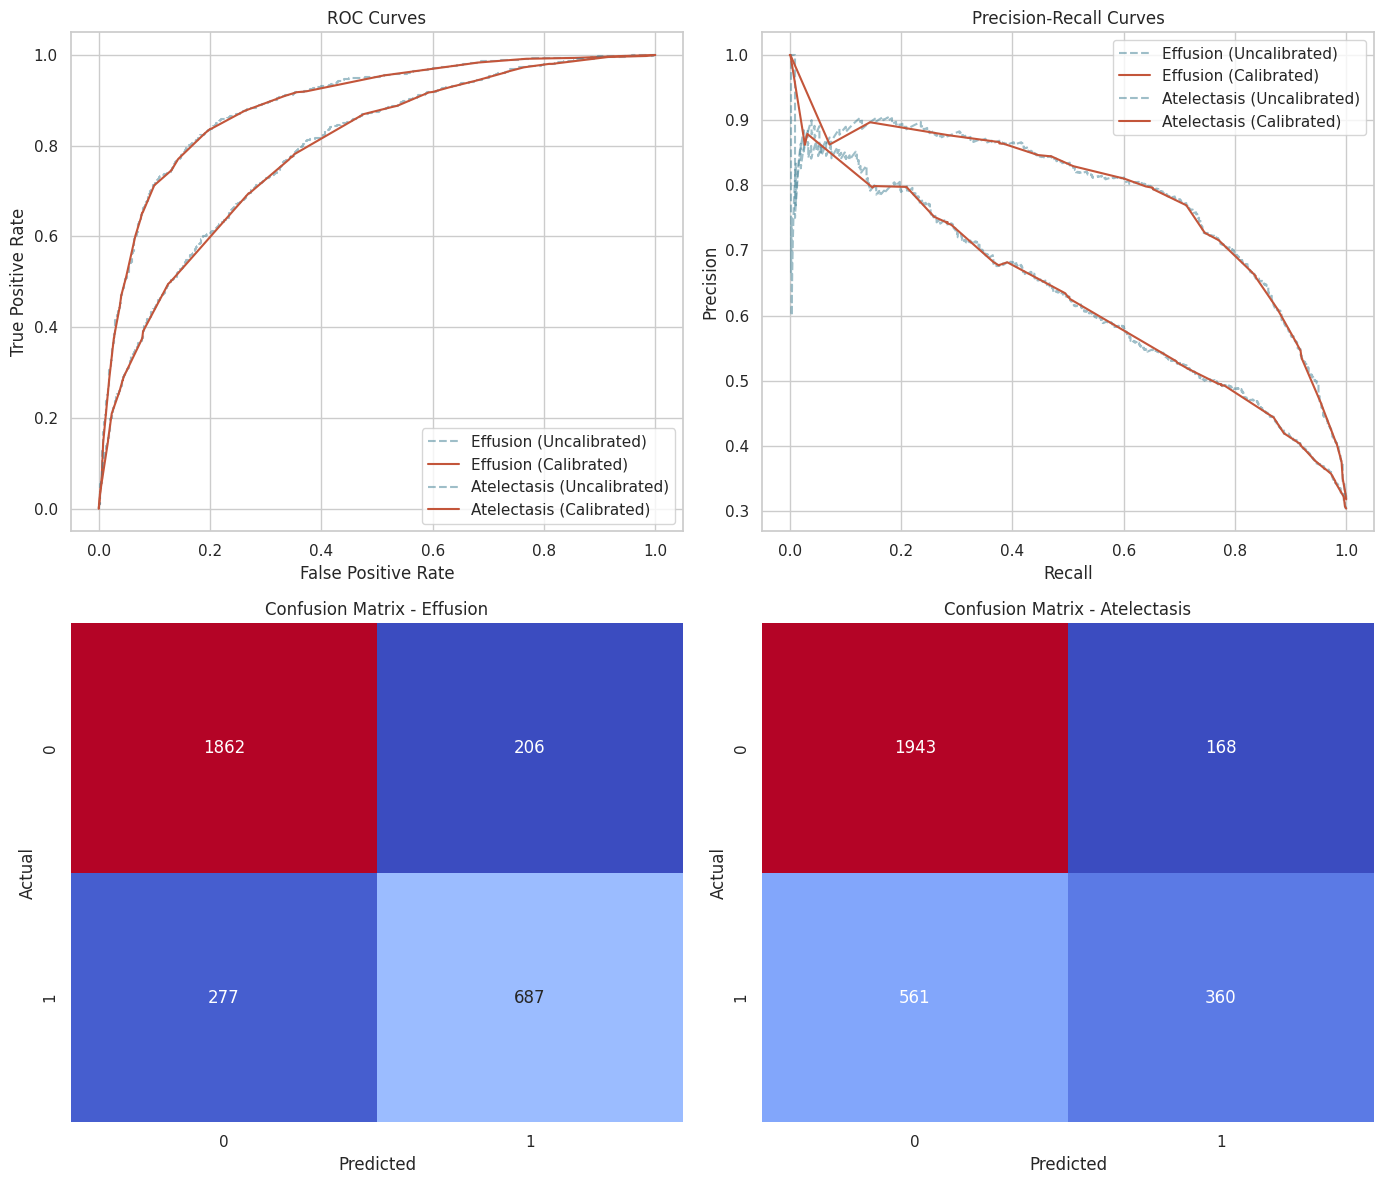

In [9]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from CNN import InfernoCalibNet, ChestXRayDataset, OUT_DIR, CALIB_DIR

sns.set_theme(style="whitegrid", palette=sns.diverging_palette(220, 20, n=2))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

def evaluate_and_calibrate():
    torch.cuda.empty_cache()

    val_dt = ChestXRayDataset(OUT_DIR / "ml_val.csv", transform=False)
    val_loader = DataLoader(val_dt, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)

    test_dt = ChestXRayDataset(OUT_DIR / "ml_test.csv", transform=False)
    test_loader = DataLoader(test_dt, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=2).to(device)
    model.load_state_dict(torch.load(CALIB_DIR / "InfernoCalibNetML.pth", weights_only=True))
    model.eval()

    def get_logits_targets(loader):
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for inputs, targets in loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                outputs = model(inputs)
                all_preds.append(outputs.cpu())
                all_targets.append(targets.cpu())
        return torch.cat(all_preds), torch.cat(all_targets)

    val_preds, val_targets = get_logits_targets(val_loader)
    test_preds, test_targets = get_logits_targets(test_loader)

    val_probs = torch.sigmoid(val_preds).numpy()
    val_targets = val_targets.numpy()
    test_probs = torch.sigmoid(test_preds).numpy()
    test_targets = test_targets.numpy()

    fig, axs = plt.subplots(2, 2, figsize=(14, 12))

    for i, label in enumerate(["Effusion", "Atelectasis"]):
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(val_probs[:, i], val_targets[:, i])
        calibrated = iso.predict(test_probs[:, i])

        pred_bin = calibrated > 0.5
        true = test_targets[:, i]

        prec = precision_score(true, pred_bin)
        rec = recall_score(true, pred_bin)
        f1 = f1_score(true, pred_bin)

        print(f"{label} ┃ Precision: {prec:.4f} ┃ Recall: {rec:.4f} ┃ F1-score: {f1:.4f}")

        fpr_cal, tpr_cal, _ = roc_curve(true, calibrated)
        prec_cal, rec_cal, _ = precision_recall_curve(true, calibrated)

        fpr_uncal, tpr_uncal, _ = roc_curve(true, test_probs[:, i])
        prec_uncal, rec_uncal, _ = precision_recall_curve(true, test_probs[:, i])

        axs[0, 0].plot(fpr_uncal, tpr_uncal, linestyle='--', alpha=0.5, label=f"{label} (Uncalibrated)")
        axs[0, 0].plot(fpr_cal, tpr_cal, label=f"{label} (Calibrated)")

        axs[0, 1].plot(rec_uncal, prec_uncal, linestyle='--', alpha=0.5, label=f"{label} (Uncalibrated)")
        axs[0, 1].plot(rec_cal, prec_cal, label=f"{label} (Calibrated)")

        cm = confusion_matrix(true, pred_bin)
        sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=False, ax=axs[1, i])
        axs[1, i].set_title(f"Confusion Matrix - {label}")
        axs[1, i].set_xlabel("Predicted")
        axs[1, i].set_ylabel("Actual")

    axs[0, 0].set_title("ROC Curves")
    axs[0, 0].set_xlabel("False Positive Rate")
    axs[0, 0].set_ylabel("True Positive Rate")
    axs[0, 0].grid(True)
    axs[0, 0].legend()

    axs[0, 1].set_title("Precision-Recall Curves")
    axs[0, 1].set_xlabel("Recall")
    axs[0, 1].set_ylabel("Precision")
    axs[0, 1].grid(True)
    axs[0, 1].legend()

    plt.tight_layout()
    plt.show()

evaluate_and_calibrate()
